# Google Colab Configuration

In [ ]:
!git clone https://github.com/emillia-q/audio-violence-detection-tinyml.git
%cd audio-violence-detection-tinyml

from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/audio-violence-detection-tflite/data.tar.gz" .
!tar -xzvf data.tar.gz

# Configuration and Imports
Importing necessary libraries.

In [7]:
# Config
import json
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import random
from pathlib import Path
from datetime import datetime
from typing import Tuple

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Scripts
from scripts.splitting import get_source_name, grouped_balanced_split

# Metrics
import joblib
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

### Set Random Seeds for Reproducibility

Setting random seeds ensures that experiments are repeatable. Crucial for comparing model performance across different runs. Set seeds for Python's built-in `random` module, `numpy` and `tensorflow`.

In [8]:
# Set random seed for Python's built-in random module
random.seed(42)

# Set random seed for NumPy
np.random.seed(42)

# Set random seed for TensorFlow
tf.random.set_seed(42)

# For deterministic behavior on GPU
tf.config.experimental.set_memory_growth(tf.config.experimental.list_physical_devices('GPU')[0], True)


# Feature Extraction Function Definitions
Defining functions to extract MFCC features and crawl the directory structure.

In [9]:
def extract_features(file_path: str | Path, n_mfcc=13) -> np.ndarray:
    """
    Returns full MFCC Matrix (time x features).
    """
    y, sr = librosa.load(str(file_path), sr=16000)

    # SANITY: exactly 32000 samples (2 sec)
    # If y is to short - add zeroes, if too long - truncate
    y = librosa.util.fix_length(y, size=32000)

    # Calculate MFCC, 2s & sr=16000 with domain params gives around 63 frames
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Preparation for CNN (time, features, channel)
    return mfcc.T[:,:,np.newaxis].astype(np.float32)

def load_dataset(processed_path: str | Path) -> Tuple[np.ndarray, np.ndarray, dict, list]:
    """
    Crawls the processed data directory to extract features from all samples
      while automatically generating a numeric label mapping based on folder names.
    """
    X, y, file_paths = [], [], []
    label_to_name = {}
    processed_dir = Path(processed_path)

    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        try:
            label = int(category_dir.name.split('_')[0])
            clean_name = category_dir.name.split('_', 1)[1].replace('_', ' ').title()
            label_to_name[label] = clean_name
        except (ValueError, IndexError):
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)
            file_paths.append(str(file_path))

    return np.array(X), np.array(y), label_to_name, file_paths

# Prepare Dataset

`load_dataset` runs MFCC extraction for every segment in `data/processed/`.

The split is **source-level and segment-balanced per class**: every original recording goes entirely to one of `train` / `val` / `test` (no leakage - `Leak check` must be all zeros) and each class is split into roughly **64% / 16% / 20%** of its **segments**, not just of its sources. This is necessary because source segment counts vary widely (one long ambient recording vs many short violence shouts), so plain source-level stratification leaves the per-class segment proportions in val/test very far from the train mix.

In [10]:
# Load data
DATA_PATH = Path('data/processed')
X, y, target_map, all_paths = load_dataset(DATA_PATH)
target_names = [target_map[i] for i in sorted(target_map.keys())]

meta = pd.DataFrame({
    "path": all_paths,
    "label": y,
    "source": [get_source_name(p) for p in all_paths],
})

train_sources, val_sources, test_sources = grouped_balanced_split(
    meta, val_size=0.16, test_size=0.20, random_state=42
)

# Filter data
train_mask = meta["source"].isin(train_sources).values
val_mask = meta["source"].isin(val_sources).values
test_mask = meta["source"].isin(test_sources).values

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train shape: {X_train.shape}")  # Should be (N, 63, 13, 1)

print("\nSegments per split:")
print(f"  train: {len(y_train):>6}")
print(f"  val:   {len(y_val):>6}")
print(f"  test:  {len(y_test):>6}")

print("\nSegments per class per split (absolute):")
counts = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(),
    "val": pd.Series(y_val).value_counts(),
    "test": pd.Series(y_test).value_counts(),
}).sort_index()
counts.index = [target_map[i] for i in counts.index]
print(counts)

print("\nClass proportions per split:")
proportions = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True),
    "val": pd.Series(y_val).value_counts(normalize=True),
    "test": pd.Series(y_test).value_counts(normalize=True),
}).sort_index().round(3)
proportions.index = [target_map[i] for i in proportions.index]
print(proportions)

print("\nPer-class share of segments going to each split:")
share = counts.div(counts.sum(axis=1), axis=0).round(3)
print(share)

# All should be 0
print("\nLeak check:")
print(f"  train ∩ val:  {len(train_sources & val_sources)}")
print(f"  train ∩ test: {len(train_sources & test_sources)}")
print(f"  val ∩ test:   {len(val_sources & test_sources)}")

Train shape: (16337, 63, 13, 1)

Segments per split:
  train:  16337
  val:     4085
  test:    5106

Segments per class per split (absolute):
          train   val  test
Ambient    5040  1261  1576
Speech     5604  1401  1751
Violence   5693  1423  1779

Class proportions per split:
          train    val   test
Ambient   0.309  0.309  0.309
Speech    0.343  0.343  0.343
Violence  0.348  0.348  0.348

Per-class share of segments going to each split:
          train   val  test
Ambient    0.64  0.16   0.2
Speech     0.64  0.16   0.2
Violence   0.64  0.16   0.2

Leak check:
  train ∩ val:  0
  train ∩ test: 0
  val ∩ test:   0


# CNN Model Architecture

In [11]:
def build_model(input_shape: Tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    """
    Creates CNN architecture optimized for TinyML.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # First splot layer (detects simple edges on sound)
        layers.Conv2D(16,(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Second splot layer (more complex formulas)
        layers.Conv2D(32,(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(input_shape=X_train.shape[1:], num_classes=len(target_map))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 63, 13, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 6, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        92,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,219 (379.76 KB)

 Trainable params: 97,219 (379.76 KB)

 Non-trainable params: 0 (0.00 B)

# Training and Evaluation

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5723 - loss: 1.0709 - val_accuracy: 0.6884 - val_loss: 0.7412
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6886 - loss: 0.7025 - val_accuracy: 0.6671 - val_loss: 0.6544
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8038 - loss: 0.4922 - val_accuracy: 0.6778 - val_loss: 0.6479
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8487 - loss: 0.4010 - val_accuracy: 0.6629 - val_loss: 0.7459
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8754 - loss: 0.3393 - val_accuracy: 0.6414 - val_loss: 0.7449
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8898 - loss: 0.2955 - val_accuracy: 0.7146 - val_loss: 0.6769
Epoch 7/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9072 - loss: 0.2564 - val_accuracy: 0.7819 - val_loss: 0.4967
Epoch 8/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9160 - loss: 0.2273 - val_accuracy: 0

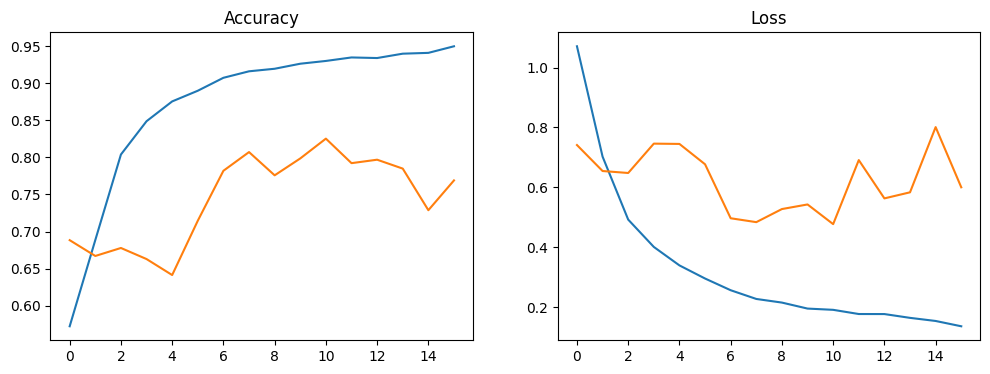

In [12]:
# Stops training when models has stopped correcting
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Charts
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val'); plt.title('Accuracy')
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val'); plt.title('Loss')
plt.show()

# Final evaluation on held-out test
Metrics match the RF notebook: accuracy, balanced accuracy, macro/weighted F1 and a full classification report. Predictions use the trained Keras model (same weights as exported TFLite).

In [13]:
y_test_proba = model.predict(X_test, batch_size=32, verbose=0)
y_test_pred = np.argmax(y_test_proba, axis=1)

acc = accuracy_score(y_test, y_test_pred)
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

print(f"Accuracy:          {acc * 100:.2f}%")
print(f"Balanced accuracy: {balanced_acc * 100:.2f}%")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")
print(classification_report(y_test, y_test_pred, target_names=target_names))

y_val_pred = np.argmax(model.predict(X_val, batch_size=32, verbose=0), axis=1)
BEST_VAL_METRICS = {
    "accuracy": float(accuracy_score(y_val, y_val_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_val, y_val_pred)),
    "macro_f1": float(f1_score(y_val, y_val_pred, average="macro")),
    "weighted_f1": float(f1_score(y_val, y_val_pred, average="weighted")),
}

TRAINING_CONFIG = {
    "epochs_max": 50,
    "batch_size": 32,
    "early_stopping_patience": 5,
    "early_stopping_monitor": "val_loss",
    "restore_best_weights": True,
    "epochs_trained": len(history.history["loss"]),
}

Accuracy:          80.55%
Balanced accuracy: 80.89%
Macro F1:          0.8053
Weighted F1:       0.8056
              precision    recall  f1-score   support

     Ambient       0.72      0.91      0.81      1576
      Speech       0.79      0.70      0.75      1751
    Violence       0.92      0.81      0.87      1779

    accuracy                           0.81      5106
   macro avg       0.81      0.81      0.81      5106
weighted avg       0.82      0.81      0.81      5106



# Versioning and serialization

Same layout as `notebooks/rf/train_model.ipynb`: versioned folders under `models/tflite` and `reports/tflite`, confusion matrix PNG, `classification_errors.csv`, `metrics.json`, and `latest_version_tflite.txt` at the **repository root** (valid after `%cd audio-violence-detection-tinyml` in Colab).

Saved artifact at '/tmp/tmpv4i1qd58'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63, 13, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132446276136848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446276138576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446276132624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446276132048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446276139536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446276139152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446276131472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446266393424: TensorSpec(shape=(), dtype=tf.resource, name=None)


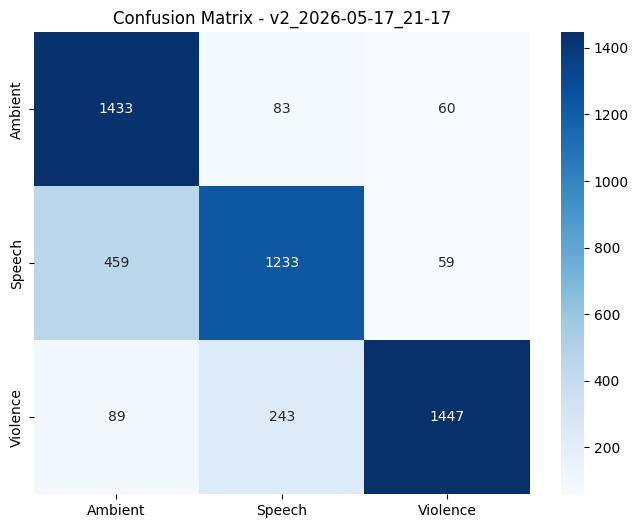

In [15]:
def get_next_version(base_path: Path) -> str:
    base_path.mkdir(parents=True, exist_ok=True)
    existing = [d.name for d in base_path.iterdir() if d.is_dir() and d.name.startswith("v")]
    version_numbers = []
    for v in existing:
        try:
            num = int(v.split("_")[0][1:])
            version_numbers.append(num)
        except ValueError:
            continue

    next_num = max(version_numbers, default=0) + 1
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

    return f"v{next_num}_{timestamp}"


BASE_DIR_MODEL = Path("models/tflite")
BASE_DIR_REPORT = Path("reports/tflite")
CURRENT_VERSION = get_next_version(BASE_DIR_MODEL)
MODEL_PATH = BASE_DIR_MODEL / CURRENT_VERSION
REPORT_PATH = BASE_DIR_REPORT / CURRENT_VERSION
MODEL_PATH.mkdir(parents=True, exist_ok=True)
REPORT_PATH.mkdir(parents=True, exist_ok=True)

model.save(MODEL_PATH / "cnn_model.keras")
joblib.dump(target_map, MODEL_PATH / "target_map.pkl")

# Directly convert the Keras model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_bytes = converter.convert()
(MODEL_PATH / "audio_detection_model.tflite").write_bytes(tflite_bytes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_test_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title(f"Confusion Matrix - {CURRENT_VERSION}")
plt.savefig(REPORT_PATH / "confusion_matrix.png")
plt.show()

analysis_df = pd.DataFrame(
    {
        "file_path": np.array(all_paths)[test_mask],
        "true_label": [target_map[i] for i in y_test],
        "predicted_label": [target_map[i] for i in y_test_pred],
    }
)
errors = analysis_df[analysis_df["true_label"] != analysis_df["predicted_label"]]
errors.to_csv(REPORT_PATH / "classification_errors.csv", index=False)

report_dict = classification_report(
    y_test, y_test_pred, target_names=target_names, output_dict=True, zero_division=0
)
metrics_payload = {
    "version": CURRENT_VERSION,
    "model": "cnn_tflite",
    "training_config": TRAINING_CONFIG,
    "val_metrics": BEST_VAL_METRICS,
    "n_train_segments": int(len(y_train)),
    "n_val_segments": int(len(y_val)),
    "n_test_segments": int(len(y_test)),
    "train_class_proportions": pd.Series(y_train).value_counts(normalize=True).sort_index().round(4).to_dict(),
    "val_class_proportions": pd.Series(y_val).value_counts(normalize=True).sort_index().round(4).to_dict(),
    "test_class_proportions": pd.Series(y_test).value_counts(normalize=True).sort_index().round(4).to_dict(),
    "test_metrics": {
        "accuracy": float(acc),
        "balanced_accuracy": float(balanced_acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    },
    "classification_report_test": report_dict,
}
with open(REPORT_PATH / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

with open("latest_version_tflite.txt", "w", encoding="utf-8") as f:
    f.write(CURRENT_VERSION)